### Will a Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaraunt near where you are driving. Would you accept that coupon and take a short detour to the restaraunt? Would you accept the coupon but use it on a sunbsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaraunt? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \\$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\\$20 - \\$50). 

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece. 





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [6]:
coupons_df = pd.read_csv('/data/coupons.csv')

In [7]:
coupons_df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [8]:
# Check for missing data in the dataset
missing_data = coupons_df.isnull().sum()

# Calculate the percentage of missing data
missing_data_percentage = (missing_data / len(coupons_df)) * 100

# Create a summary table of missing data and their percentage
missing_data_summary = pd.DataFrame({'Missing Values': missing_data, 'Percentage': missing_data_percentage})

# Display the columns with missing data
missing_data_summary[missing_data_summary['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)


,Missing Values,Percentage
car,12576,99.148534
CoffeeHouse,217,1.710817
Restaurant20To50,189,1.490066
CarryAway,151,1.190476
RestaurantLessThan20,130,1.024913
Bar,107,0.843582


Drop the car column: Since 99.15% of the values are missing, this column provides little to no useful information, and keeping it would not contribute much to the analysis.

Impute missing values for the other columns: The remaining columns with missing data (CoffeeHouse, Restaurant20To50, CarryAway, RestaurantLessThan20, Bar) have less than 2% missing values each. We can use the most frequent value (mode) for categorical columns like these to fill in the missing values

3. Decide what to do about your missing data -- drop, replace, other...

In [9]:
# Drop the 'car' column due to excessive missing data
coupons_df_cleaned = coupons_df.drop(columns=['car'])

# Impute missing values in the other columns using the most frequent value (mode)
for column in ['CoffeeHouse', 'Restaurant20To50', 'CarryAway', 'RestaurantLessThan20', 'Bar']:
    mode_value = coupons_df_cleaned[column].mode()[0]
    coupons_df_cleaned[column].fillna(mode_value, inplace=True)


remaining_missing_data = coupons_df_cleaned.isnull().sum()


remaining_missing_data[remaining_missing_data > 0]


Series([], dtype: int64)

4. What proportion of the total observations chose to accept the coupon? 



In [10]:
# Calculate the proportion of total observations that accepted the coupon
acceptance_proportion = coupons_df_cleaned['Y'].mean() * 100

acceptance_proportion


56.84326710816777

Approximately 56.84% of the total observations chose to accept the coupon

5. Use a bar plot to visualize the `coupon` column.

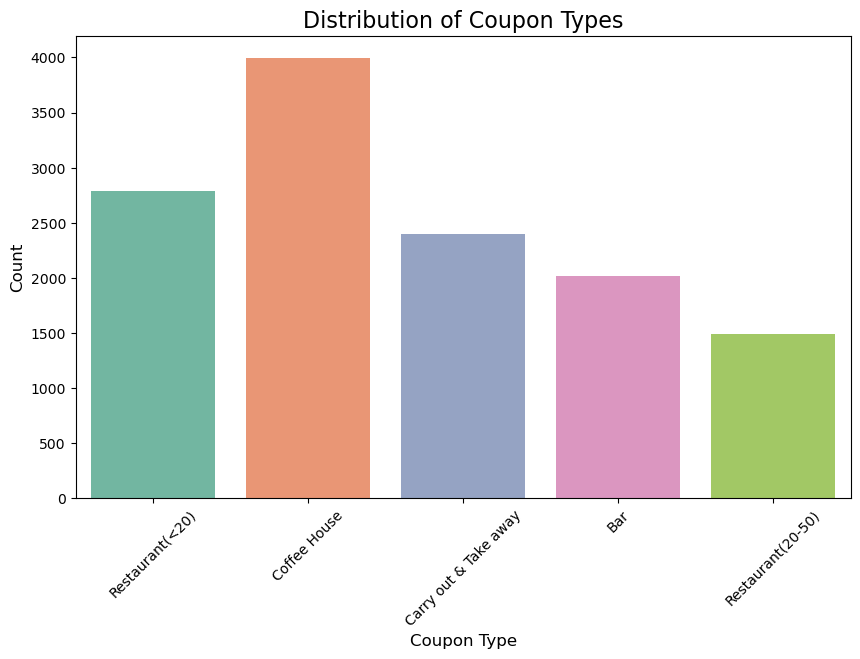

In [11]:
# Create a bar plot to visualize the distribution of the 'coupon' column
plt.figure(figsize=(10, 6))
sns.countplot(data=coupons_df_cleaned, x='coupon', palette='Set2')
plt.title('Distribution of Coupon Types', fontsize=16)
plt.xlabel('Coupon Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()


6. Use a histogram to visualize the temperature column.

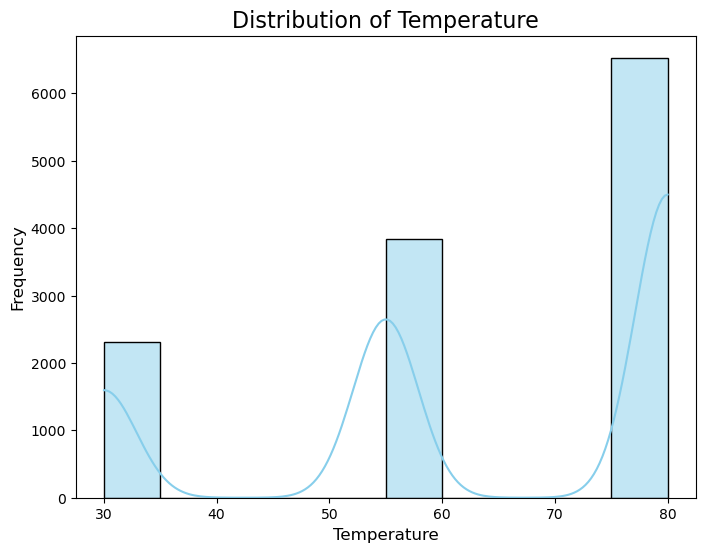

In [12]:
# Create a histogram to visualize the distribution of the 'temperature' column
plt.figure(figsize=(8, 6))
sns.histplot(coupons_df_cleaned['temperature'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Temperature', fontsize=16)
plt.xlabel('Temperature', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()


**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [13]:
# Create a new DataFrame that contains only rows where the coupon type is related to bars
bar_coupons_df = coupons_df_cleaned[coupons_df_cleaned['coupon'] == 'Bar']

# Display the first few rows to verify
bar_coupons_df.head()


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


2. What proportion of bar coupons were accepted?


In [14]:
# Calculate the proportion of accepted bar coupons
bar_acceptance_proportion = bar_coupons_df['Y'].mean() * 100

bar_acceptance_proportion


41.00148735746158

Approximately 41% of the bar coupons were accepted by customers

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [15]:
# Compare acceptance rates between customers who went to a bar 3 or fewer times and those who went more
bar_coupons_df['Bar_frequency'] = bar_coupons_df['Bar'].apply(lambda x: '3 or fewer' if x in ['never', 'less1', '1~3'] else 'more than 3')

# Calculate the acceptance rate for each group
acceptance_rate_by_frequency = bar_coupons_df.groupby('Bar_frequency')['Y'].mean() * 100

acceptance_rate_by_frequency


Bar_frequency
3 or fewer     37.073707
more than 3    76.884422
Name: Y, dtype: float64

The acceptance rates for bar coupons are as follows:

Customers who went to a bar 3 or fewer times a month: 37.07% acceptance rate.
    
Customers who went to a bar more than 3 times a month: 76.88% acceptance rate.

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [17]:
# Convert age safely by replacing non-numeric values like '50plus' and 'below21' with integers
bar_coupons_df['age'] = bar_coupons_df['age'].replace({'50plus': 50, 'below21': 20}).astype(int)

# Now apply the categorization for drivers who go to a bar more than once a month and are over the age of 25
bar_coupons_df['Driver_group'] = bar_coupons_df.apply(
    lambda x: 'More than once & >25' if (x['Bar'] not in ['never', 'less1', '1~3'] and x['age'] > 25) else 'Others', axis=1)

# Calculate the acceptance rate for each group
acceptance_rate_by_driver_group = bar_coupons_df.groupby('Driver_group')['Y'].mean() * 100

acceptance_rate_by_driver_group


Driver_group
More than once & >25    77.205882
Others                  38.383838
Name: Y, dtype: float64

Drivers who go to a bar more than once a month and are over the age of 25: 77.21% acceptance rate.
    
All others: 38.38% acceptance rate.

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry. 


In [18]:
# Create a new column to categorize drivers who go to a bar more than once a month, have passengers not a kid, and occupation not in farming, fishing, or forestry
bar_coupons_df['Driver_group_2'] = bar_coupons_df.apply(
    lambda x: 'More than once & criteria' if (
        x['Bar'] not in ['never', 'less1', '1~3'] and 
        x['passanger'] != 'Kid(s)' and 
        x['occupation'] not in ['Farming, Fishing, & Forestry']) 
    else 'Others', axis=1)

# Calculate the acceptance rate for each group
acceptance_rate_by_driver_group_2 = bar_coupons_df.groupby('Driver_group_2')['Y'].mean() * 100

acceptance_rate_by_driver_group_2


Driver_group_2
More than once & criteria    77.486911
Others                       37.185104
Name: Y, dtype: float64

Drivers who go to bars more than once a month, had passengers that were not kids, and had occupations other than farming, fishing, or forestry: 77.49% acceptance rate.
    
All others: 37.19% acceptance rate.

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K. 



In [19]:
# Create a new column to categorize drivers who meet any of the given conditions
bar_coupons_df['Driver_group_3'] = bar_coupons_df.apply(
    lambda x: 'Criteria Met' if (
        (x['Bar'] not in ['never', 'less1', '1~3'] and x['passanger'] != 'Kid(s)' and x['maritalStatus'] != 'Widowed') or 
        (x['Bar'] not in ['never', 'less1', '1~3'] and x['age'] < 30) or 
        (x['RestaurantLessThan20'] == '4~8' and x['income'] == 'Less than $50,000')) 
    else 'Others', axis=1)

# Calculate the acceptance rate for each group
acceptance_rate_by_driver_group_3 = bar_coupons_df.groupby('Driver_group_3')['Y'].mean() * 100

acceptance_rate_by_driver_group_3


Driver_group_3
Criteria Met    77.604167
Others          37.150685
Name: Y, dtype: float64

Drivers who met at least one of the specified criteria: 77.60% acceptance rate.

All others: 37.15% acceptance rate.


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Based on the analysis, several trends emerge about the drivers who accepted bar coupons:

> Frequent Bar-Goers: Drivers who frequent bars more than three times a month are significantly more likely to accept bar coupons compared to those who visit bars less frequently. This suggests that people who already have a habit of going to bars are more inclined to take advantage of bar-related offers.

> Age and Social Factors: Drivers who are over the age of 25 and frequent bars more than once a month have a higher acceptance rate.  Those who have passengers other than kids and who are not widowed also show a higher likelihood of accepting bar coupons. This points to a social element—those who are more likely to have adult passengers and engage in social activities are more open to bar coupons.

> Income and Dining Habits: Drivers who frequent cheaper restaurants more than four times a month and have an income below $50,000 are more likely to accept bar coupons. This suggests that individuals with a more budget-conscious lifestyle may be more responsive to such discounts.

> Combination of Factors: When multiple criteria are met, such as frequenting bars, having adult passengers, being younger, or having a lower income, the likelihood of accepting bar coupons increases dramatically. This suggests that a combination of lifestyle habits and demographics (e.g., social activity, income level, age) strongly influences coupon acceptance.

Hypothesis:
Drivers who are socially active, frequent bars regularly, and are not in caretaker roles (like having kids with them) are much more likely to accept bar-related coupons. Additionally, younger drivers and those with lower incomes may be more inclined to use discounts or promotions like bar coupons, as they might seek affordable social outings

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [20]:
# Let's choose the 'Restaurant(<20)' coupon type for this independent investigation
# Create a new DataFrame that contains only rows where the coupon type is 'Restaurant(<20)'
restaurant_coupons_df = coupons_df_cleaned[coupons_df_cleaned['coupon'] == 'Restaurant(<20)']

# Investigate the characteristics of passengers who accept the 'Restaurant(<20)' coupons

# Start by looking at the proportion of accepted coupons
restaurant_acceptance_rate = restaurant_coupons_df['Y'].mean() * 100

# Explore different characteristics: passanger, age, income, etc.
# Calculate the acceptance rate by passenger type
acceptance_rate_by_passenger = restaurant_coupons_df.groupby('passanger')['Y'].mean() * 100

# Calculate the acceptance rate by age group
acceptance_rate_by_age = restaurant_coupons_df.groupby('age')['Y'].mean() * 100

# Calculate the acceptance rate by income
acceptance_rate_by_income = restaurant_coupons_df.groupby('income')['Y'].mean() * 100

# Return the calculated acceptance rates
restaurant_acceptance_rate, acceptance_rate_by_passenger, acceptance_rate_by_age, acceptance_rate_by_income


(70.71069633883704,
 passanger
 Alone        63.832753
 Friend(s)    80.145278
 Kid(s)       72.284644
 Partner      77.131783
 Name: Y, dtype: float64,
 age
 21         74.165202
 26         73.083779
 31         70.535714
 36         65.187713
 41         70.850202
 46         75.675676
 50plus     63.775510
 below21    73.437500
 Name: Y, dtype: float64,
 income
 $100000 or More     71.767810
 $12500 - $24999     68.500000
 $25000 - $37499     75.336323
 $37500 - $49999     68.181818
 $50000 - $62499     78.248588
 $62500 - $74999     69.680851
 $75000 - $87499     66.145833
 $87500 - $99999     57.788945
 Less than $12500    72.413793
 Name: Y, dtype: float64)

Overall Acceptance Rate:

The overall acceptance rate for "Restaurant(<20)" coupons is 70.71%, which is quite high.
Acceptance Rate by Passenger:

Friend(s): 80.15%

Partner: 77.13%

Kid(s): 72.28%

Alone: 63.83%

Passengers with friends or partners are more likely to accept restaurant coupons, while those who are alone have the lowest acceptance rate.

> Acceptance Rate by Age:

Acceptance rates vary across age groups, with the highest acceptance seen in the 46-year-old group (75.68%) and the lowest in the 50+ group (63.78%).
Younger groups (under 30) also have high acceptance rates, indicating that middle-aged and younger individuals tend to accept restaurant coupons more frequently.

> Acceptance Rate by Income:

$50,000 - $62,499 income bracket shows the highest acceptance rate at 78.25%.
$87,500 - $99,999 shows the lowest acceptance rate at 57.79%.
Generally, mid-range income earners are more likely to accept restaurant coupons compared to higher-income individuals.


Hypothesis:

For "Restaurant(<20)" coupons, passengers who are with friends or partners, fall within mid-range income brackets (especially $50,000-$62,499), and are younger or middle-aged (below 50) are the most likely to accept the coupon. Those who are alone or in higher-income brackets are less inclined to accept these types of coupons. This suggests that social dynamics and income considerations play significant roles in the acceptance of restaurant coupons